In [1]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def imshow(img, title=None):
    plt.figure(figsize=(10,6))
    plt.axis('on')
    plt.title(title)
    plt.imshow(img, cmap='gray')
    plt.show()

In [3]:
# dataset path
cPath = 'C:/Users/Acer/Documents/ISWAN DATAS/ORB ALGORITHM/DATASET/FINGERPRINT DATASET/dataset/clean_line'
paths = glob.glob(os.path.join(cPath, '*.bmp'))

In [4]:
orb = cv2.ORB_create()

In [5]:
images = []
descriptors = []
keypoints_list = []

In [6]:

# DATABASE
for path in paths:
    img = cv2.imread(path, 0)
    kp, des = orb.detectAndCompute(img, None)

    images.append(img)
    descriptors.append(des)
    keypoints_list.append(kp)


In [7]:
# QUERY IMAGE
Qimage = cv2.imread('C:/Users/Acer/Documents/ISWAN DATAS/ORB ALGORITHM/DATASET/FINGERPRINT DATASET/dataset/data_test/1__M_Left_index_finger.bmp', 0)

Qkp, Qdes = orb.detectAndCompute(Qimage, None)

In [8]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

best_match_img = None
best_score = float('inf')
best_kp = None


In [9]:
# SEARCH BEST MATCH
for idx, des in enumerate(descriptors):

    if des is not None and Qdes is not None and Qdes.shape[1] == des.shape[1]:

        matches = bf.match(Qdes, des)

        score = sum(m.distance for m in matches) / len(matches)

        if score < best_score:
            best_score = score
            best_match_img = images[idx]
            best_kp = keypoints_list[idx]
            best_matches = matches
            best_path = paths[idx]

In [ ]:

final_img = cv2.drawMatches(
    Qimage, Qkp,
    best_match_img, best_kp,
    sorted(best_matches, key=lambda x: x.distance)[:20],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)


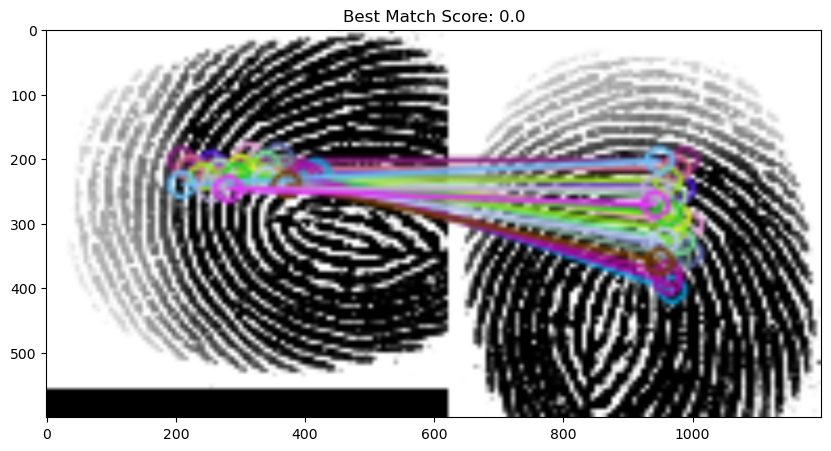

In [ ]:

final_img = cv2.resize(final_img, (1200, 600))


final_img = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)

imshow(final_img, f"Best Match Score: {best_score}")